<img src="logo_UNSAM.jpg" align="right" width="150">

#### Análisis y Procesamiento de Señales

# *TS3 - Análisis de Fourier: FFT, desparramo, interpolación y ventaneo*

### *Autora: Catalina Gonzalez Araujo*

### *Docentes: Mariano Llamedo Soria, David Ezequiel Benoit, Francisco Hernan Ledesma.*

# <u>**Resumen**</u>
En este trabajo se estudió el fenómeno de desparramo espectral que se produce al calcular la *DFT* (*Discret Fourir Transform*) de una señal senoidal de potencia normalizada, es decir energía o varianza unitaria. Se consideraron diferentes frecuencias ($f_0 = k_0 \cdot \frac{f_s}{N} = k_0 \cdot \Delta f$) cercanas a múltiplos de la resolución espectral $\Delta f$, variando el indice $k_0$ como $N/4$, $N/4 + 0.25$ y $N/4 + 0.5$. 

En la primera parte, se calculó y graficó, para cada caso, las densidades espectrales de potencia (*PDS*), mostrando cómo una pequeña desintonía respecto a $\Delta f$ provoca una distribución de la energía en varios bins en lugar de concentrarse en uno solo. 

Luego, se verificó mediante la *identidad de Parseval* que la potencia total de cada señal se conserva en el dominio frecuencial, y se discutió por qué dos senoidales con frecuencias muy cercanas pueden producir espectros tan distintos, a pesar de tener la misma energía.

Finalmente, se repitió el experimento aplicando *zero padding*, agregando $9N$ ceros al final de la señal para aumentar $\Delta f$. Se discutieron las ventajas de esta técnica y se analizaron los resultados obtenidos. 

# <u>**Introducción teórica**</u>
La **Transformada Discreta de Fourier (*DFT*)** es una herramienta fundamental en el análisis de señales digitales, ya que permite representar una señal temporal en el dominio de la frecuencia. A nivel computacional, su cálculo se realiza de manera eficiente mediante el algoritmo de la **Transformada Rápida de Fourier** (*FFT*), lo que reduce el costo computacional sin alterar el resultado matemático.

Para comprender la *FFT* se expresa la *DFT* para *N-puntos*: 
$$
X[k] = \sum_{n = 0}^{N - 1} x[n] \cdot e^{-j \cdot \frac{2 \pi}{N} \cdot k \cdot n} = \sum_{n = 0}^{N - 1} x[n] \cdot W_{N}^{k \cdot n} \quad \text{(1)}
$$

donde $W_{N} = e^{-j \cdot \frac{2 \pi}{N}}$.

La *DFT* es una transformación lineal que transforma $x[n]$ en $X[k]$. Podemos pensar a la transformada como una "caja" que toma *N* puntos de $x[n]$ como entrada, y devuelve *N* puntos de $X[k]$ como salida. 

El objetivo de la *FFT* es evaluar a la *DFT* rápido. Para ello, se separa la entrada de la *FFT* en dos subsecuencias de $\frac{N}{2}$ puntos, $x_1[n]$ que representa los valores pares de la entrada, y $x_2[n]$ los impares. Entonces la ecuación *(1)* queda representada como:
$$
X[k] = \sum_{n = 0}^{N - 1} x[n] \cdot W_{N}^{k \cdot n} = \sum_{n = 0}^{N/2 - 1} x[2 \cdot n] \cdot W_{N}^{k \cdot 2 \cdot n} + \sum_{n = 0}^{N/2 - 1} x[2 \cdot n + 1] \cdot W_{N}^{k \cdot (2 \cdot n + 1)} = \sum_{n = 0}^{N/2 - 1} x_1[n] \cdot W_{N}^{k \cdot 2 \cdot n} + \sum_{n = 0}^{N/2 - 1} x_2[n] \cdot W_{N}^{k \cdot (2 \cdot n + 1)} \quad \text{(2)}
$$

Cada sumatoria representa la mitad de la original. Además: $W_{N}^{k \cdot 2 \cdot n} = e^{-j \cdot \frac{2 \pi}{N} \cdot k \cdot 2 \cdot n} = e^{-j \cdot \frac{2 \pi}{N/2} \cdot k \cdot n} = W_{N/2}^{k \cdot n}$ y $W_{N}^{k \cdot (2 \cdot n + 1)} = e^{-j \cdot \frac{2 \pi}{N} \cdot k \cdot (2 \cdot n + 1)} = e^{-j \cdot \frac{2 \cdot \pi}{N} \cdot k \cdot 2 \cdot n} \cdot e^{-j \cdot \frac{2 \cdot \pi}{N} \cdot k} = W_{N/2}^{k \cdot n} \cdot W_{N}^{k}$

Por lo tanto, la ecuación $\quad \text{2}$ resulta en:
$$
X[k] = \sum_{n = 0}^{N/2 - 1} x_1[n] \cdot W_{N/2}^{k \cdot n} + W_{N}^{k} \cdot \sum_{n = 0}^{N/2 - 1} x_2[n] \cdot W_{N/2}^{k \cdot n} = X_1[k] + W_{N}^{k} \cdot X_2[k] \quad 0 \leq k < N
$$

Cada uno de los factores $W_{N}^{k}$ se denominan *twiddle factors*, porque el efecto de multiplicar $X_2[k]$ por un twiddle factor $W_{N}^{k} = e^{-j \cdot \frac {2 \cdot \pi}{N} \cdot k}$ es rotar la fase en $\frac {-2 \cdot \pi \cdot k} {N}$ antes de sumar el resultado de $X_1[k]$.

Las *DFTs* parciales ($X_1[k]$ y $X_2[k]$) son periódicas con período $N/2$, lo cual permite reutilizar los resultados de los primeros $N/2$ valores para obtener los restantes. Entonces, podemos decir que una *DFT* con $N/2$ - puntos, es periódica de período $N/2$. 
$$
X_1[k + N/2] = X_1[k]
X_2[k + N/2] = X_2[k]
$$
con $0 \leq k < N/2$. 

Siendo asi que, cada valor de $N/2$ - puntos de la *DFT* ($X_1[k]$ y $X_2[k]$) es usado dos veces, una para computar $X[k]$ y otra para computar $X[k + N/2]$.

Al trabajar con secuencias finitas, de longitud *N* y discretas, aparecen fenómenos propios de la *DFT* que no ocurren en el análisis continuo.

Uno de estos fenómenos es el **desparramo espectral (spectral leakage)**. Este efecto se produce cuando la frecuencia de la señal no coincide exactamente con un múltiplo entero de la resolución espectral de la *DFT* ($\Delta f = f_s/N$, donde $f_s$ es la frecuencia de muestreo, y $N$ es el número de muestras). En estos casos, la energía de la senoidal no se concentra en un único bin de frecuencia, sino que se distribuye entre varios.

Este desparramo se debe a que la *DFT* asume que la señal es periódica en ventanas de longitud $N$. Si la senoidal no completa un número entero de ciclos dentro de esa ventana, al replicarse aparecen discontinuidades, que se manifiestan en el dominio frecuencial como el ensanchamiento de la energía.

Por otro lado, la **identidad de Parseval** asegura que la potencia total de la señal se conserva entre el dominio temporal y el frecuencial, aunque la forma en que se distribuye en el espectro depende de la sintonía de la frecuencia. En el caso discreto, esta identidad se representa mediante la siguiente ecuación: 
$$
\sum_{n = 0}^{N - 1} |x[n]|^2 = \frac{1}{N} \cdot \sum_{k = 0}^{N - 1}|X[k]|^2
$$

De este modo, aunque la energía se "desparrame" en el espectro, la potencia total se mantiene invariante.

Otra manera de verificar la potencia unitaria de una secuencia es mediante el cálculo de la **varianza**, la cual se define mediante la siguiente ecuación: 
$$
\sigma^2 = \frac{1}{N} \cdot \sum_{n = 0}^{N - 1}(x[n] - \bar{x})^2 
$$
donde $\bar{x}$ es la media de la señal.

Entonces podemos interpretar a la varianza como una medida de la potencia media de la señal. En el caso particular de señales de media cero, la varianza coincide con el valor cuadrático medio (*RMS*), y por lo tanto con la potencia promedio. 

Finalmente, una técnica muy utilizada para mejorar la visualización del espectro es el **zero padding**, que consiste en añadir ceros al final de la señal antes de aplicar la FFT. Esto no incrementa la información frecuencial real ni mejora la resolución espectral efectiva ($\Delta f$), pero sí interpola el espectro, permitiendo observar con mayor detalle la forma de los lóbulos generados por el desparramo espectral.

# <u>**Análisis y desarrollo**</u>

Para todos los ítems del ejercicio planteado por la cátedra, se realizaron todos los gráficos en *dB* (decibelio), lo que significa que, en vez de graficar la magnitud lineal de la señal, se expresa en una escala logarítmica. Esto se hace para una mejor visualización del rango dinámico, y para mayor facilidad de interpretación de los gráficos. 

A continuación, se detallan los procedimientos realizados para cumplir con las consignas propuestas, junto con un análisis de los resultados obtenidos.

<h4 style="color:red;">a) <u>Efecto de la desintonía en el espectro</u></h4>

En esta experiencia se generaron cuatro senoidales de longitud $N = 1000$ y frecuencia de muestreo $f_s = N$. 

Se consideraron distintas frecuencias para cada una: 
$$
f_0 = \frac{N}{4}
$$
$$
f_0 = \frac{N}{4} + 0.25
$$
$$
f_0 = \frac{N}{4} + 0.5
$$
$$
f_0 = \frac{N}{4} + 1 \quad \text{(extra agregado en clase)}
$$

In [11]:
#%% LLamo a las librerias que se van a utilizar
import numpy as np
import matplotlib.pyplot as plt

# Parametros
fs = 1000 
N = 1000
k0 = N/4
f0 = k0 * fs/N 
ts = 1/fs
tt = np.arange(N) * ts
df = fs/N # Resolucion temporal

# Eje de frecuencias
freqs = np.arange(0, fs, df)

#%% k0 = N/4
# Señal (potencia unitaria)
vmax = np.sqrt(2)
dc = 0
x = dc + vmax * np.sin(2*np.pi*f0*tt)

# FFT
X = np.fft.fft(x)
Xmod = (np.abs(X) / N)**2
Xmod_db = 10 * np.log10(Xmod * 2 + 1e-12)

# Fase
X_fase = np.angle(X)

# Eje de frecuencias
freqs = np.arange(0, fs, df)

#%% k0 = N/4 + 0.25

k0 = N/4 + 0.25
f0 = k0 * fs/N 
ts = 1/fs
tt = np.arange(N) * ts

# Señal (potencia unitaria)
vmax = np.sqrt(2)
dc = 0
x1 = dc + vmax * np.sin(2*np.pi*f0*tt)

# FFT
X1 = np.fft.fft(x1)
Xmod1 = (np.abs(X1) / N)**2
Xmod_db1 = 10 * np.log10(Xmod1 * 2 + 1e-12)

# Fase
X_fase1 = np.angle(X1)

#%% k0 = N/4 + 0.5

k0 = N/4 + 0.5
f0 = k0 * fs/N 
ts = 1/fs
tt = np.arange(N) * ts

# Señal (potencia unitaria)
vmax = np.sqrt(2)
dc = 0
x2 = dc + vmax * np.sin(2*np.pi*f0*tt)

# FFT
X2 = np.fft.fft(x2)
Xmod2 = (np.abs(X2) / N)**2
Xmod_db2 = 10 * np.log10(Xmod2 * 2 + 1e-12)

# Fase
X_fase2 = np.angle(X2)

#%% k0 = N/4 + 1

k0 = N/4 + 1
f0 = k0 * fs/N 
ts = 1/fs
tt = np.arange(N) * ts

# Señal (potencia unitaria)
vmax = np.sqrt(2)
dc = 0
x3 = dc + vmax * np.sin(2*np.pi*f0*tt)

# FFT
X3 = np.fft.fft(x3)
Xmod3 = (np.abs(X3) / N)
Xmod_db3 = 10 * np.log10(Xmod3 * 2 + 1e-12)

# Fase
X_fase3 = np.angle(X3)

Es decir, en cada caso a la frecuencia de la señal se le agrega una desintonía respecto a $\Delta f$. 

En primer lugar se graficó el módulo de cada una de las señales.

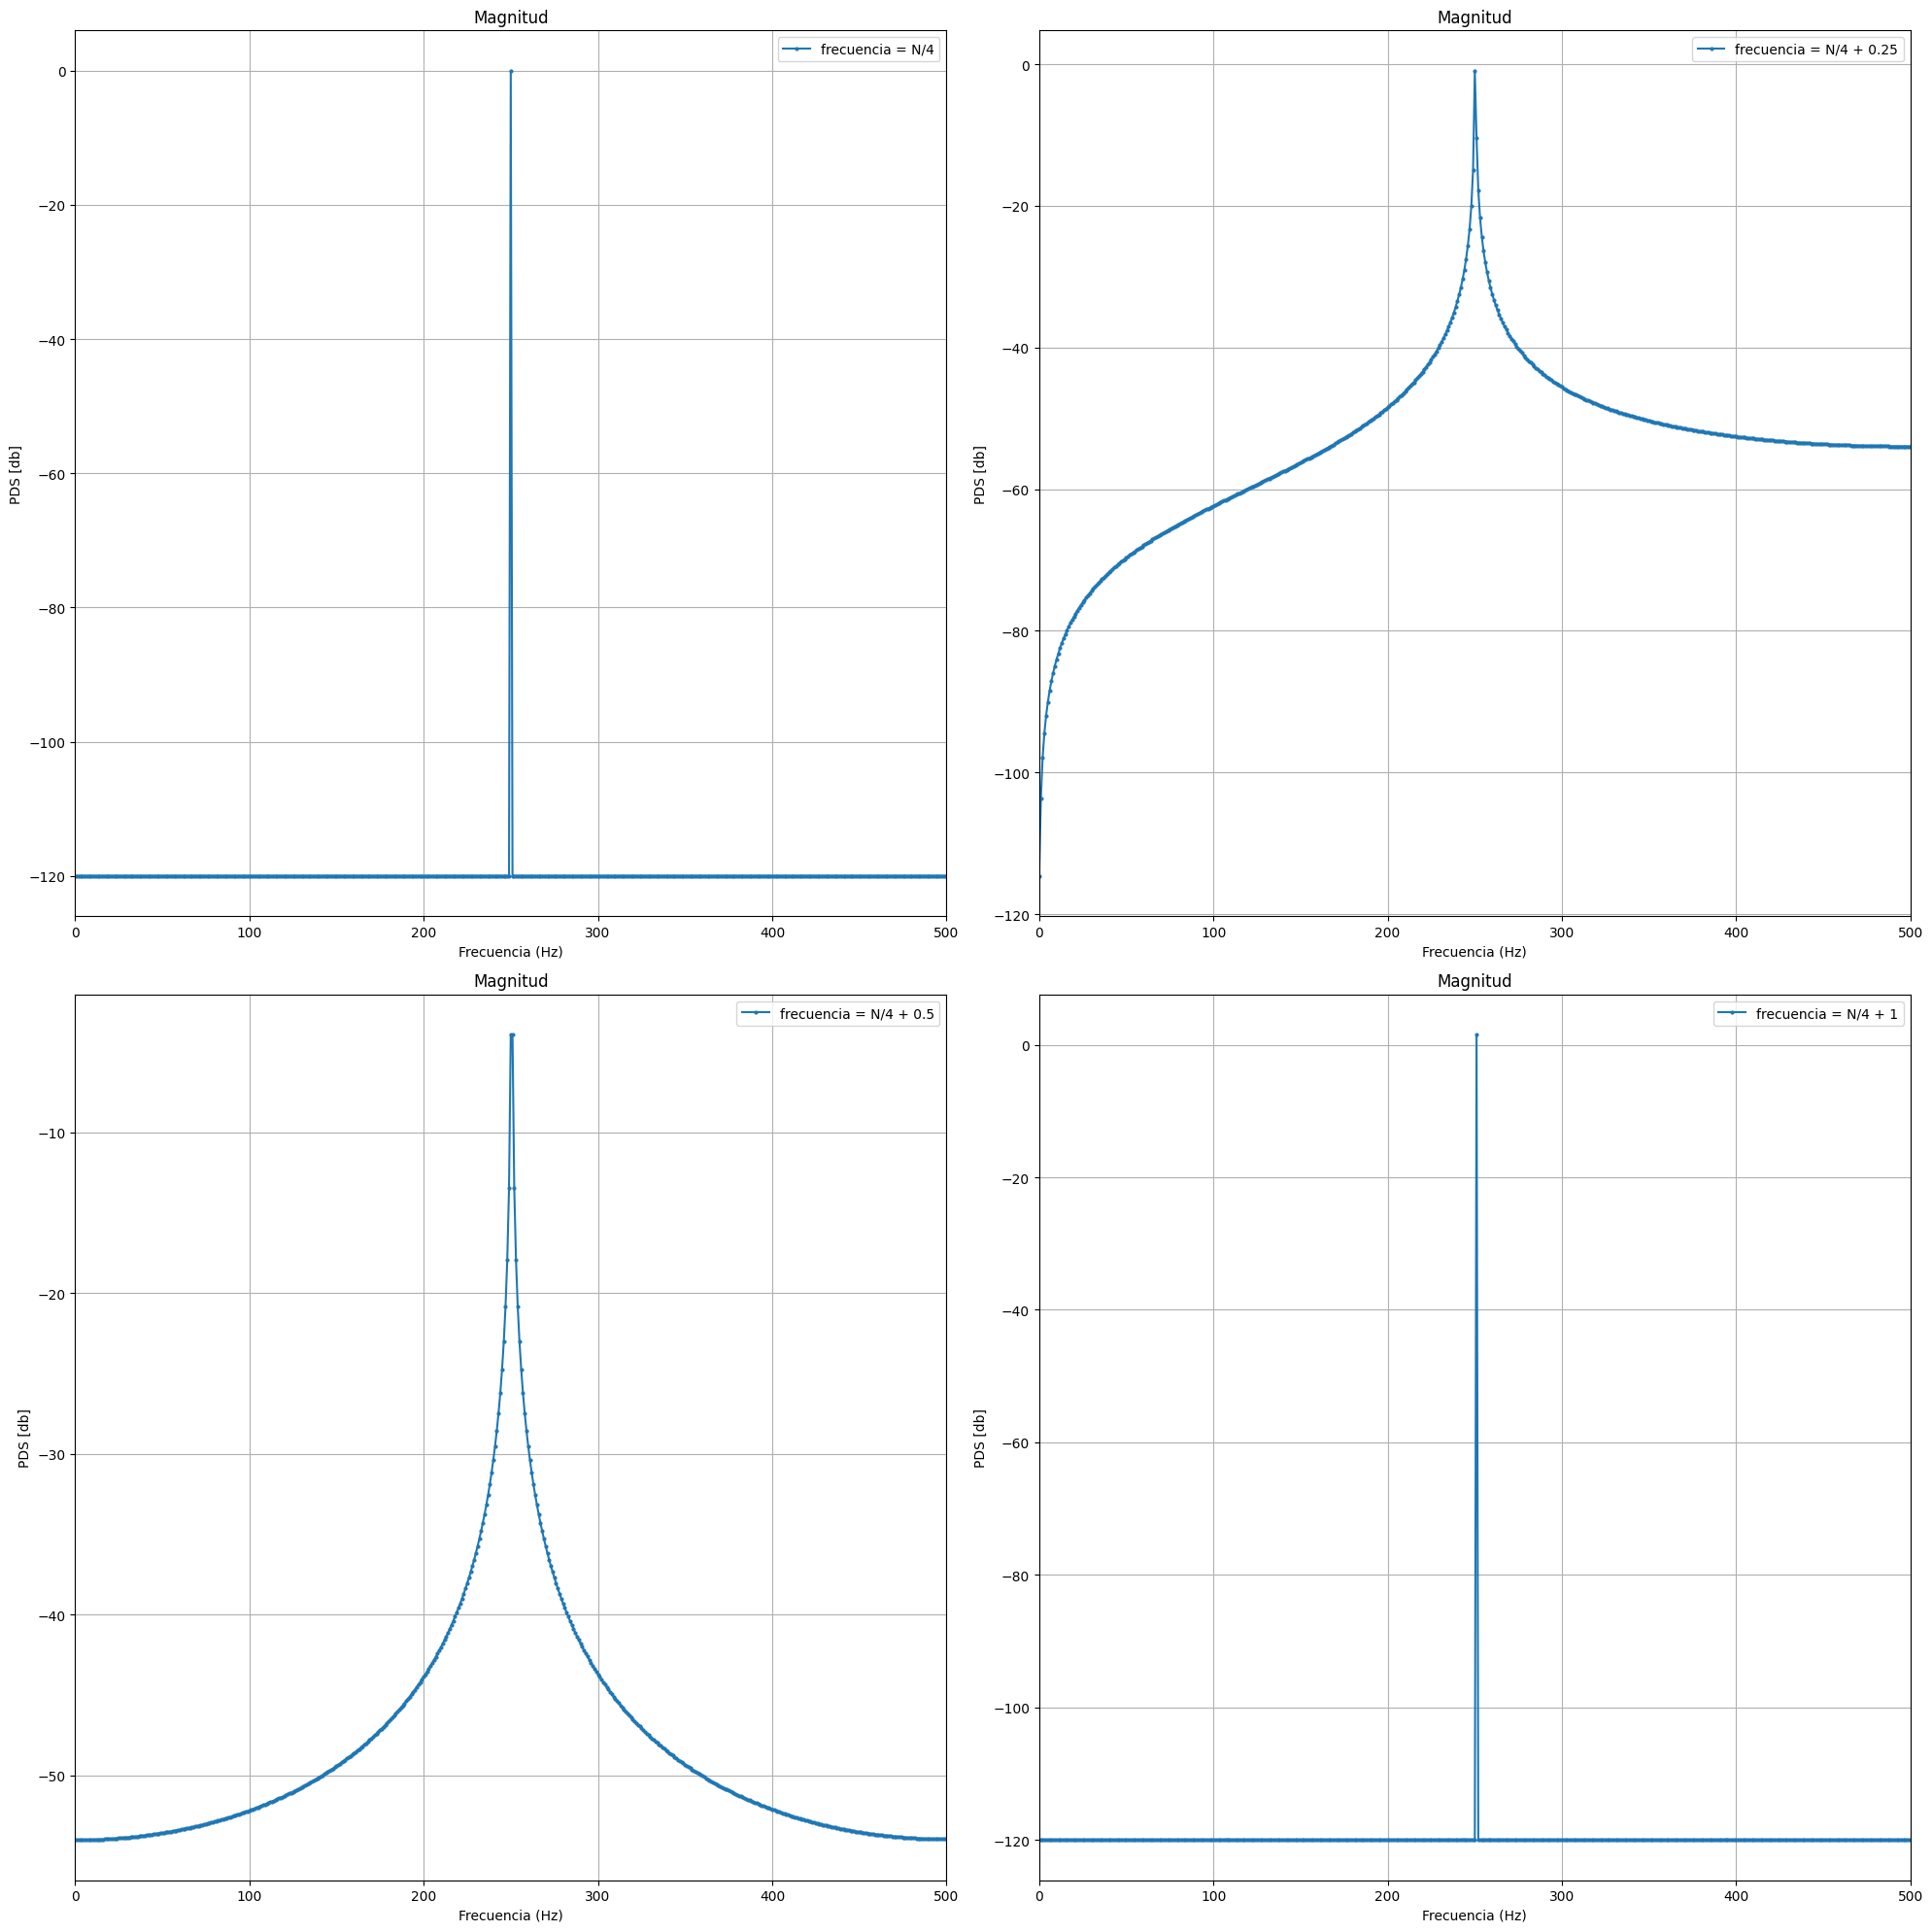

In [12]:
# GRAFICOS 
# MODULO 
# N/4
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.subplot(2, 2, 1)
plt.title("Magnitud")
plt.plot(freqs, Xmod_db, marker = 'o', markersize = 2, label = 'frecuencia = N/4')
plt.xlim([0, fs/2]) # Es un espectro par 
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PDS [db]')

plt.legend()
plt.grid()

# N/4 + 0.25
plt.subplot(2, 2, 2)

plt.title("Magnitud")
plt.plot(freqs, Xmod_db1, marker = 'o', markersize = 2, label = 'frecuencia = N/4 + 0.25')
plt.xlim([0, fs/2]) # Es un espectro par 
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PDS [db]')

plt.legend()
plt.grid()

# N/4 + 0.5
plt.subplot(2, 2, 3)
plt.title("Magnitud")
plt.plot(freqs, Xmod_db2, marker = 'o', markersize = 2, label = 'frecuencia = N/4 + 0.5')
plt.xlim([0, fs/2]) # Es un espectro par 
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PDS [db]')

plt.legend()
plt.grid()

# N/4 + 1
plt.subplot(2, 2, 4)
plt.title("Magnitud")
plt.plot(freqs, Xmod_db3, marker = 'o', markersize = 2, label = 'frecuencia = N/4 + 1')
plt.xlim([0, fs/2]) # Es un espectro par 
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PDS [db]')

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Seguido a eso se graficó la fase para cada caso. 

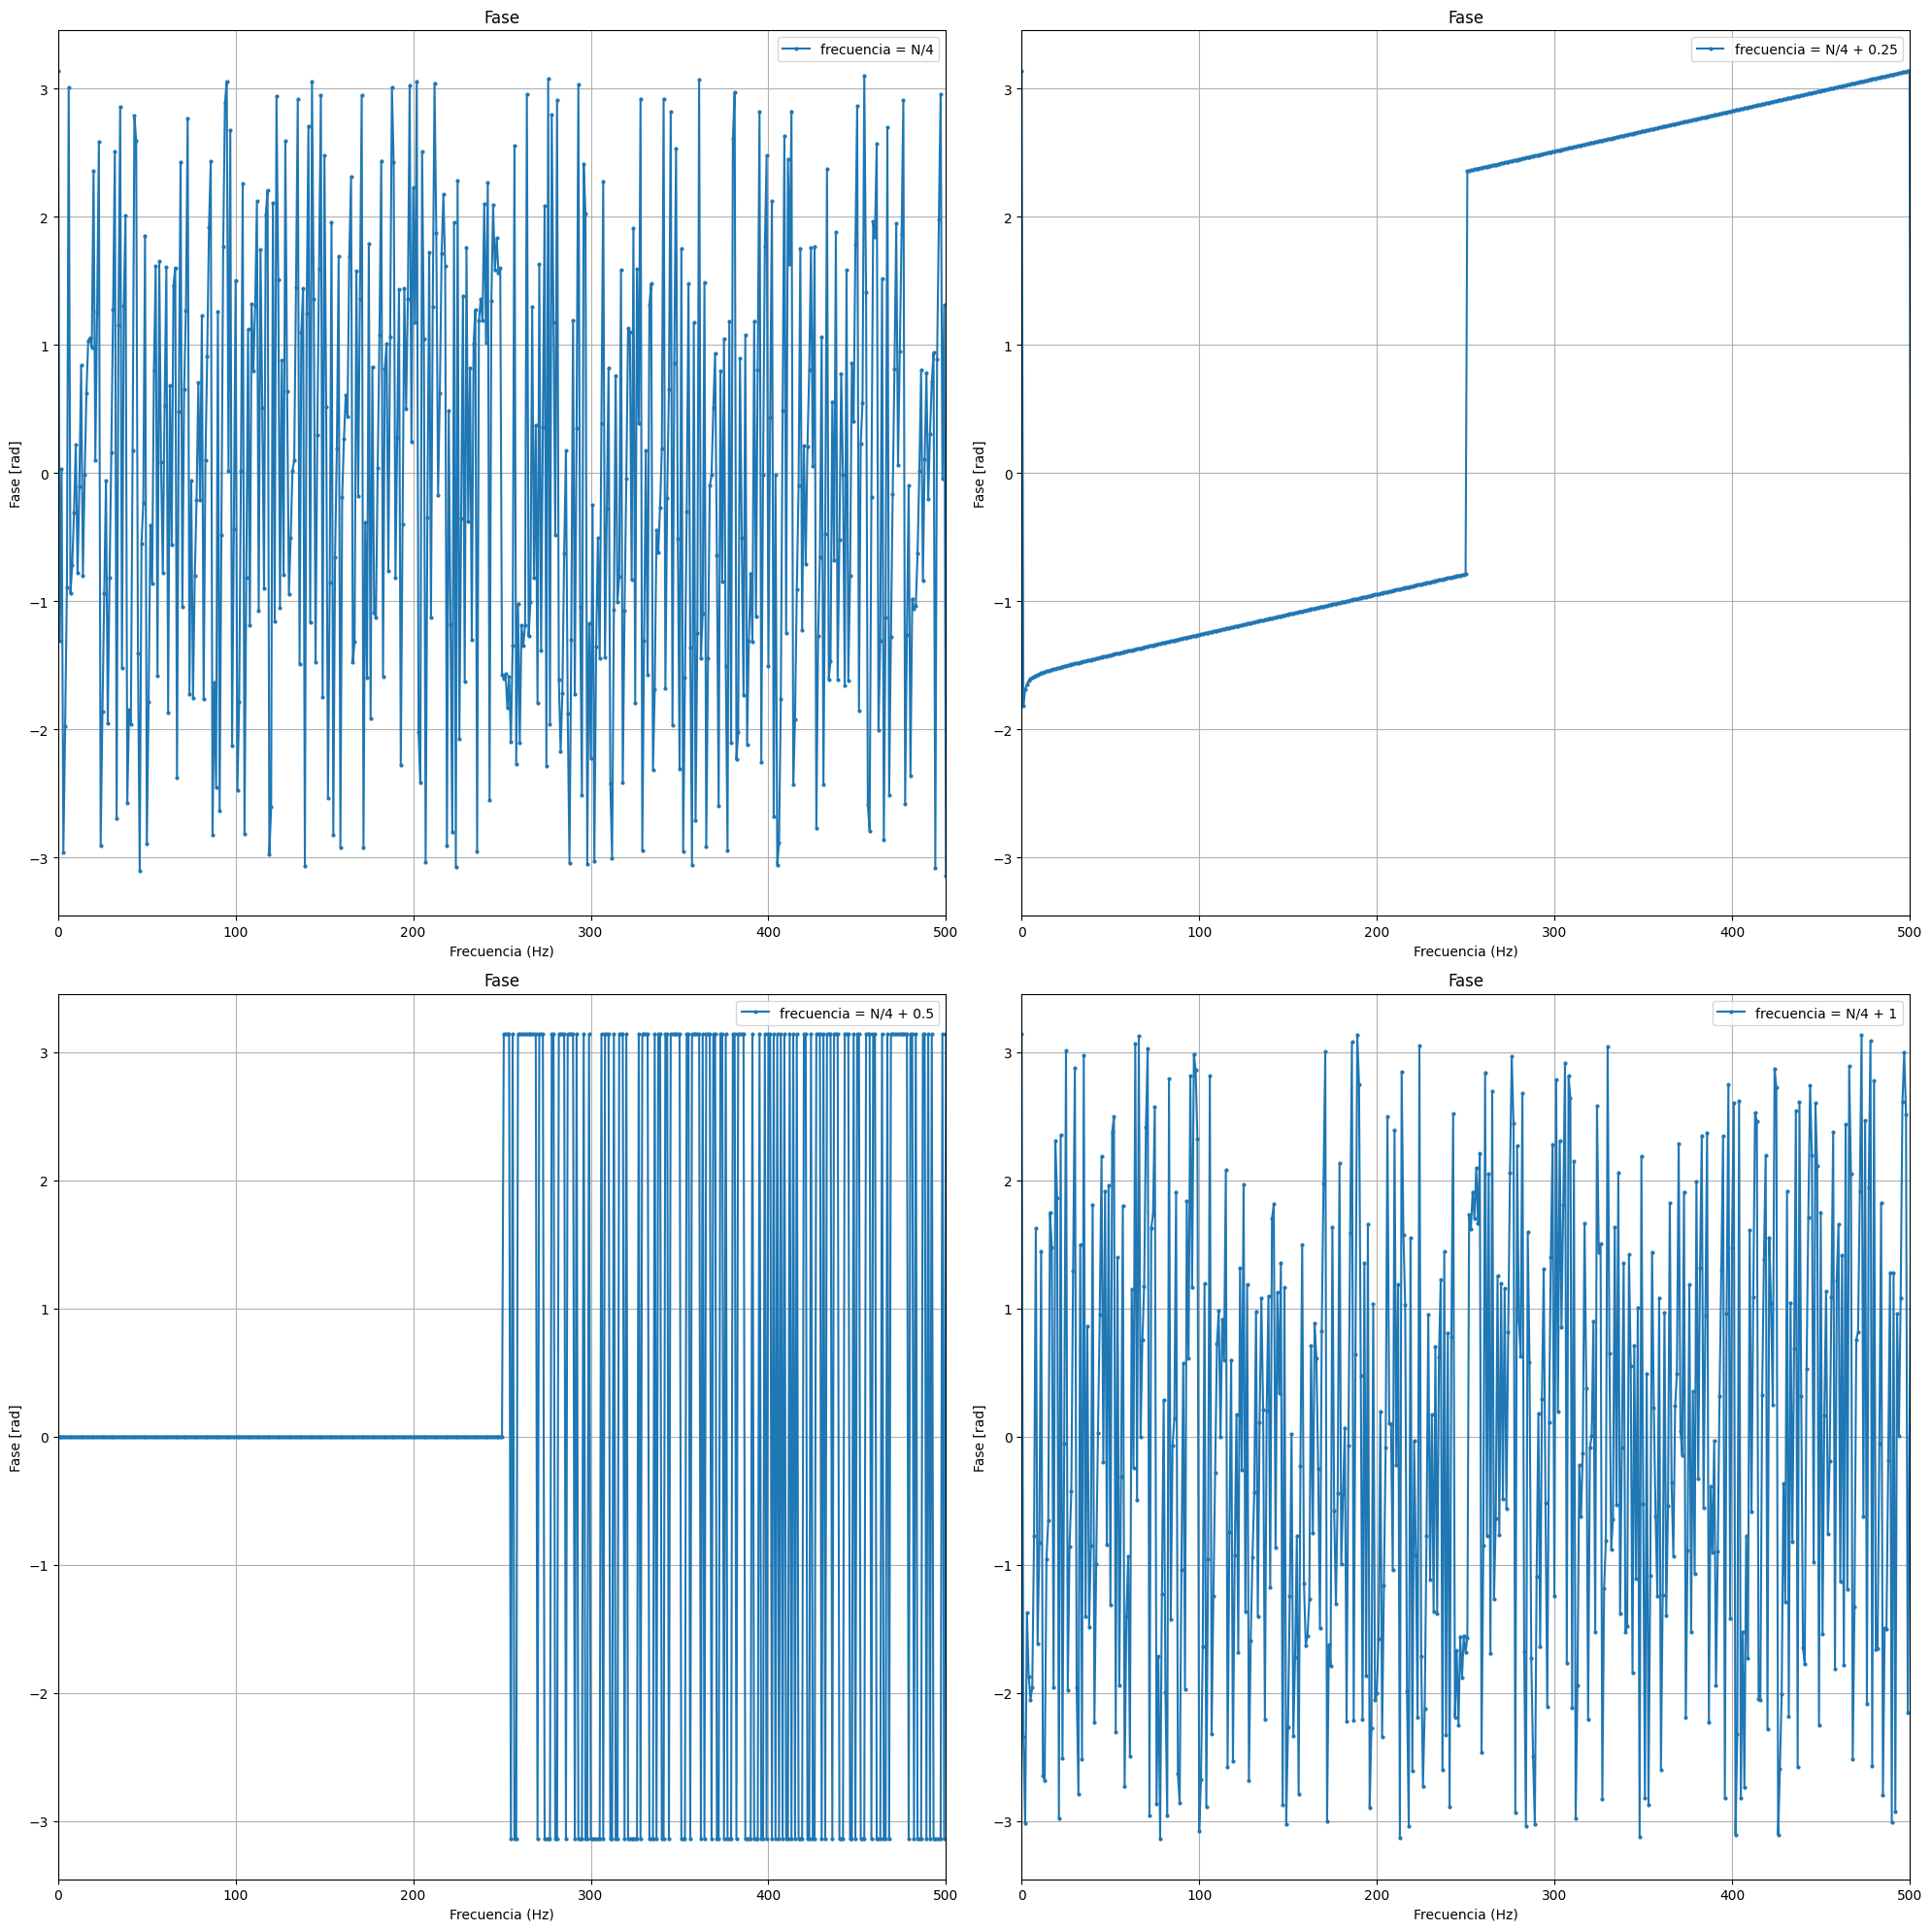

In [13]:
# GRAFICOS 
# FASE 
plt.figure(figsize = (20, 20))

# N/4
plt.subplot(2, 2, 1)
plt.title("Fase")
plt.plot(freqs, X_fase, marker = 'o', markersize = 2, label = 'frecuencia = N/4')
plt.xlim([0, fs/2]) # Es un espectro par 
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Fase [rad]')

plt.grid()
plt.legend()

# N/4 + 0.25
plt.subplot(2, 2, 2)
plt.title("Fase")
plt.plot(freqs, X_fase1, marker = 'o', markersize = 2, label = 'frecuencia = N/4 + 0.25')
plt.xlim([0, fs/2]) # Es un espectro par 
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Fase [rad]')

plt.grid()
plt.legend()

# N/4 + 0.5
plt.subplot(2, 2, 3)
plt.title("Fase")
plt.plot(freqs, X_fase2, marker = 'o', markersize = 2, label = 'frecuencia = N/4 + 0.5')
plt.xlim([0, fs/2]) # Es un espectro par 
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Fase [rad]')

plt.grid()
plt.legend()

# N/4 + 1
plt.subplot(2, 2, 4)
plt.title("Fase")
plt.plot(freqs, X_fase3, marker = 'o', markersize = 2, label = 'frecuencia = N/4 + 1')
plt.xlim([0, fs/2]) # Es un espectro par 
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Fase [rad]')

plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

Lo que se buscó fue observar el efecto de la desintonía agregada a cada senoidal en el espectro visualizado.  

<h4 style="color:red;">b) <u>Verificación de la potencia unitaria</u></h4>

En esta parte, se verificó la potencia unitaria de cada señal. Para ello, se eligió una amplitud de $A = \sqrt{2}$, de manera tal que la potencia de la señal resulte  unitaria 
$$ 
P = \frac{A^2}{2} = \frac{(\sqrt{2})^2}{2} = 1
$$

Esto implica que las señales poseen potencia normalizada (o varianza unitaria). 

La verificación se realizó tanto en el dominio temporal como en el dominio frecuencial. 

- En el tiempo se calculó la potencia mediante el valor medio cuadrático de la señal, obteniendo valores cercanos a 1 (diferencias atribuibles a redondeo numércio).
- En frecuencia, se corroboró que se cumple la identidad de parseval utilizando la *DFT* normalizada. Los resultados obtenidos coincidieron con los calculos en el dominio temporal, comprobando así la conservación de la energía entre ambos dominios.

In [14]:
#%% Identidad de parseval
print(f"{'Identidad de Parseval':^150}\n")  # título centrado en 60 caracteres

#%% FRECUENCIA N/4 
# Potencia en tiempo
P_tiempo = np.mean(x**2)

# Potencia en frecuencia
P_freq = np.sum(np.abs(X/N)**2)

print(f"{'------ Senoidal con frecuencia = N/4 ------':^150}")
print(f"{f'Potencia temporal = {P_tiempo:.4f}':^150}")
print(f"{f'Potencia frecuencial = {P_freq:.4f}':^150}")

#%% FRECUENCIA N/4 + 0.25 
# Potencia en tiempo
P_tiempo1 = np.mean(x1**2)

# Potencia en frecuencia
P_freq1 = np.sum(np.abs(X1/N)**2)

print(f"{'------ Senoidal con frecuencia = N/4 + 0.25 ------':^150}")
print(f"{f'Potencia temporal = {P_tiempo1:.4f}':^150}")
print(f"{f'Potencia frecuencial = {P_freq1:.4f}':^150}")

#%% FRECUENCIA N/4 + 0.5 
# Potencia en tiempo
P_tiempo2 = np.mean(x2**2)

# Potencia en frecuencia
P_freq2 = np.sum(np.abs(X2/N)**2)

print(f"{'------ Senoidal con frecuencia = N/4 + 0.5 ------':^150}")
print(f"{f'Potencia temporal = {P_tiempo2:.4f}':^150}")
print(f"{f'Potencia frecuencial = {P_freq2:.4f}':^150}")

#%% FRECUENCIA N/4 + 1 
# Potencia en tiempo
P_tiempo3 = np.mean(x3**2)

# Potencia en frecuencia
P_freq3 = np.sum(np.abs(X3/N)**2)

print(f"{'------ Senoidal con frecuencia = N/4 + 1 ------':^150}")
print(f"{f'Potencia temporal = {P_tiempo3:.4f}':^150}")
print(f"{f'Potencia frecuencial = {P_freq3:.4f}':^150}")

                                                                Identidad de Parseval                                                                 

                                                     ------ Senoidal con frecuencia = N/4 ------                                                      
                                                              Potencia temporal = 1.0000                                                              
                                                            Potencia frecuencial = 1.0000                                                             
                                                  ------ Senoidal con frecuencia = N/4 + 0.25 ------                                                  
                                                              Potencia temporal = 0.9990                                                              
                                                            Potencia frecuencial = 0.9990    

<h4 style="color:red;">c) <u>Efecto del zero padding</u></h4>

Para finalizar este trabajo se aplicó la técnica de *zero padding*, añadiendo $9N$ ceros al final de cada señal antes de calcular la FFT. 

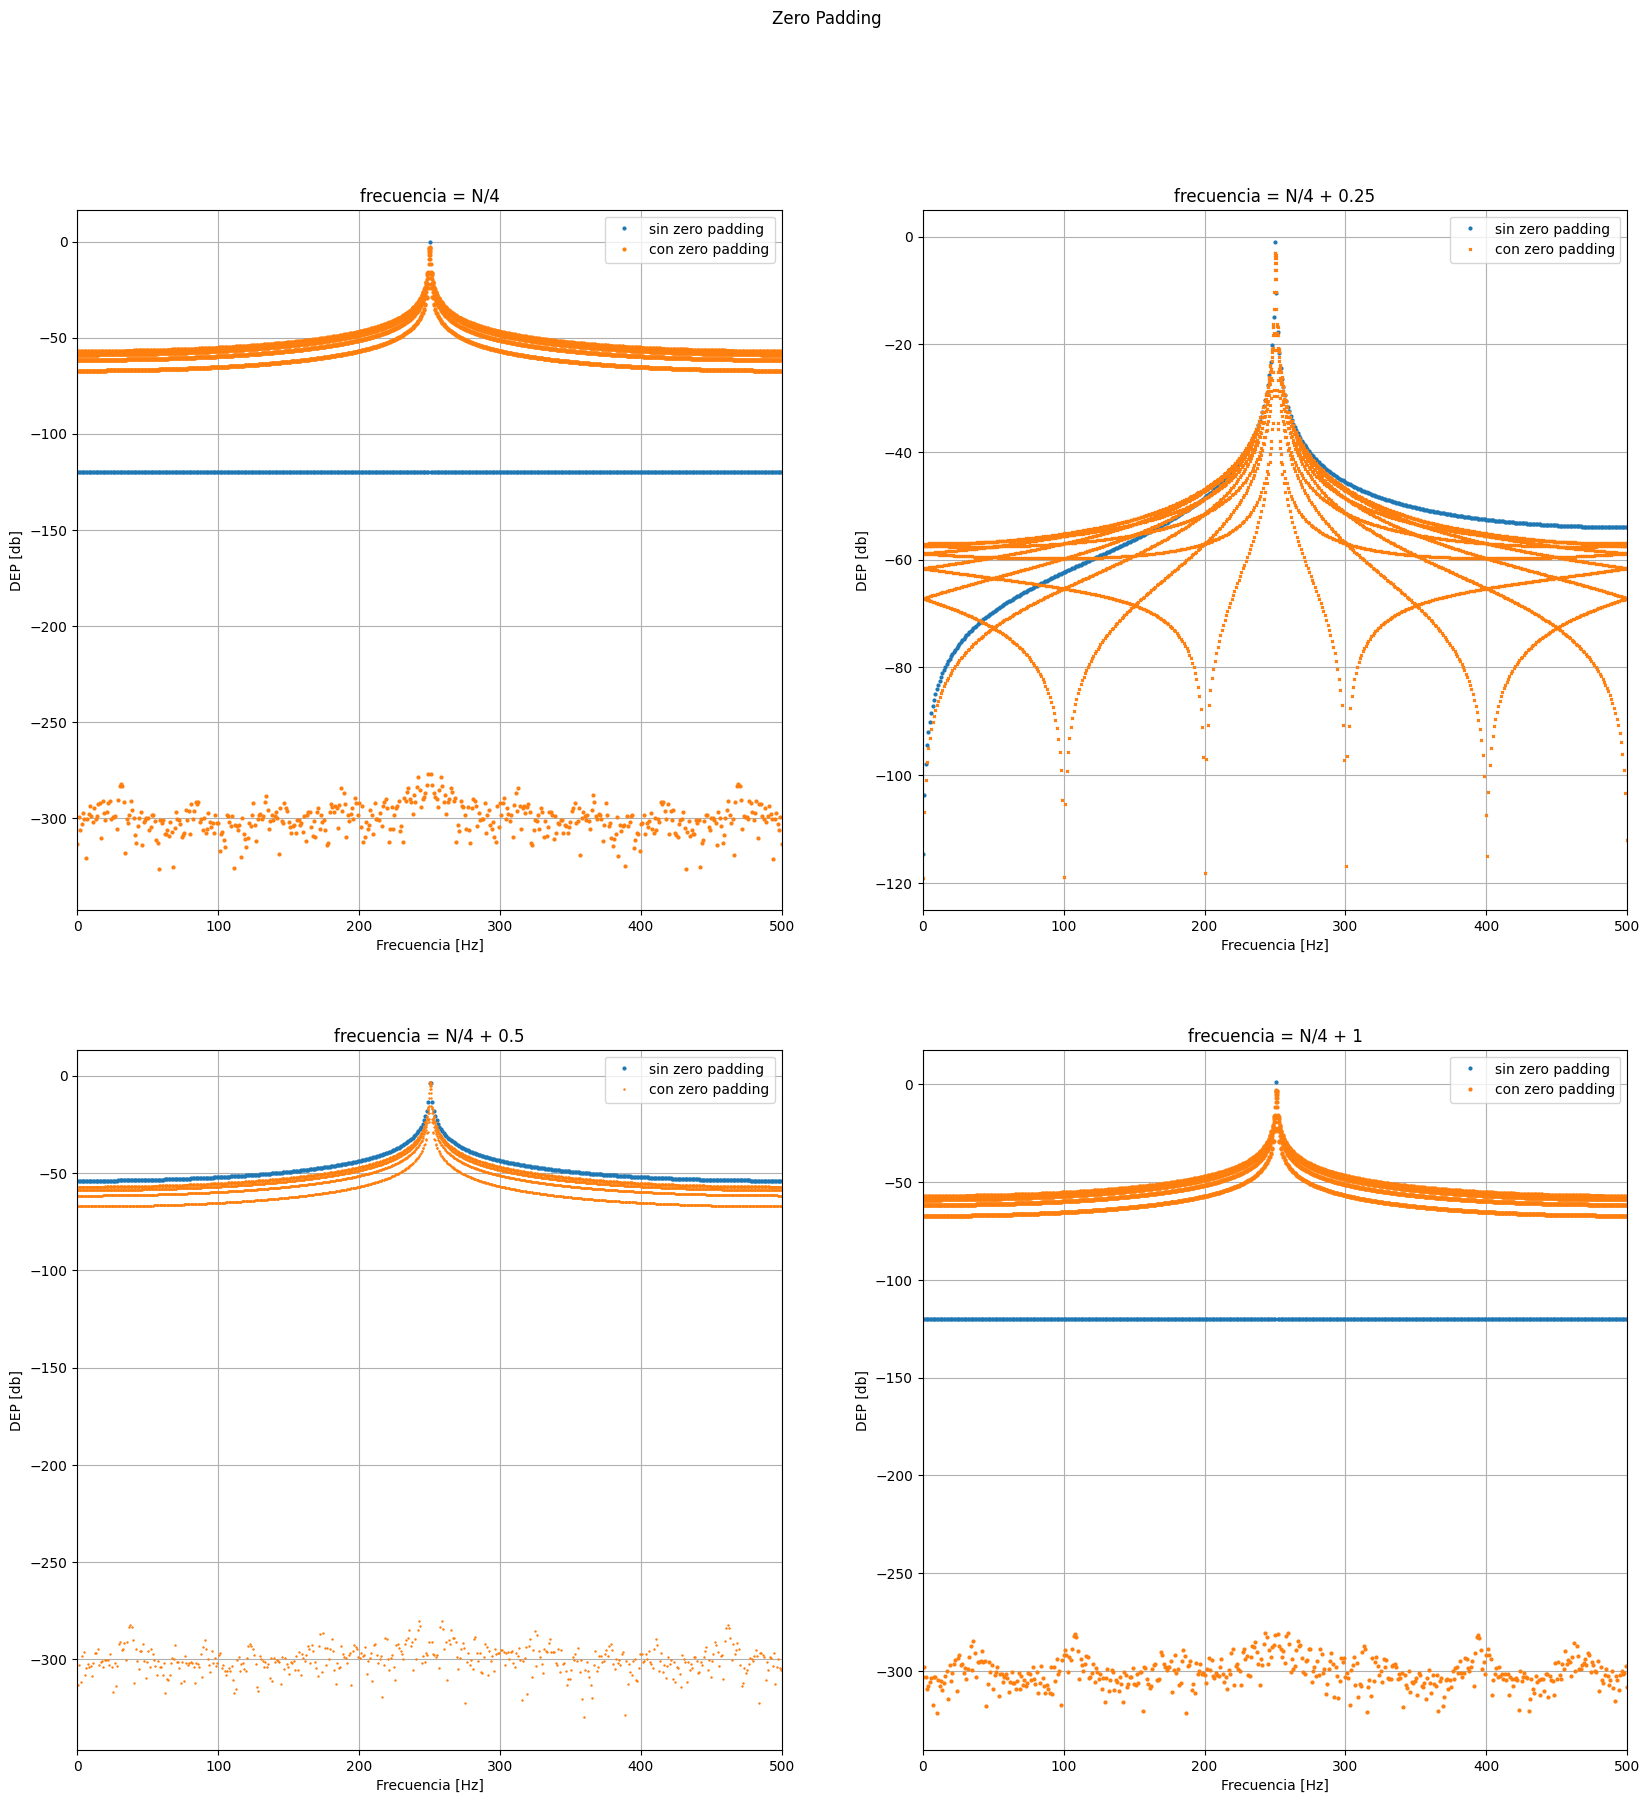

In [15]:
#%% ZERO PADDING
# Vector de ceros de tamaño 9 * N
cant_zp = 9
zp = np.zeros(cant_zp * N) 

# La funcion "concatenate" une dos secuencias en una sola
# --> La uso para crear la cajita (ventana) que vale 1 hasta N - 1, y cero desde ahi hasta (2N - 1)
xp = np.concatenate((x, zp)) 
xp1 = np.concatenate((x1, zp))
xp2 = np.concatenate((x2, zp))
xp3 = np.concatenate((x3, zp))

# muestras_zp = cant_zp * N + N # Estoy agregando ceros para que la señal me quede de longitud 10N

# Calculo la FFT
Xp = np.fft.fft(xp) / N
Xp1 = np.fft.fft(xp1) / N
Xp2 = np.fft.fft(xp2) / N
Xp3 = np.fft.fft(xp3) / N

# Modulos
Xp_mod = np.abs(Xp)**2
Xp_mod1 = np.abs(Xp1)**2
Xp_mod2 = np.abs(Xp2)**2
Xp_mod3 = np.abs(Xp3)**2

# FFT en dB
Xp_dB = 10 * np.log10(Xp_mod)
Xp_dB1 = 10 * np.log10(Xp_mod1)
Xp_dB2 = 10 * np.log10(Xp_mod2)
Xp_dB3 = 10 * np.log10(Xp_mod3)

# Fase 
Xp_fase = np.angle(Xp)

# Ejes de frecuencia
Npadding = len(xp)
df_padding = fs / Npadding
ff_padding = np.arange(Npadding) * df_padding 

# Grafico en db
plt.figure(figsize = (20, 20))
plt.suptitle("Zero Padding") # DEP = Densidad Espectral de Potencia --> PSD

# frecuencia = N/4
plt.subplot(2, 2, 1)
plt.title("frecuencia = N/4")
plt.plot(freqs, Xmod_db, marker = 'o', markersize = 2, label = "sin zero padding", linestyle='none')
plt.plot(ff_padding, Xp_dB, 'o', markersize = 2, label = 'con zero padding')
plt.xlim(0, fs/2)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("DEP [db]")
plt.legend()
plt.grid()

# frecuencia = N/4 + 0.25
plt.subplot(2, 2, 2)
plt.title("frecuencia = N/4 + 0.25")
plt.plot(freqs, Xmod_db1, marker = 'o', markersize = 2, label = "sin zero padding", linestyle='none')
plt.plot(ff_padding, Xp_dB1, 'x', markersize = 2, label = 'con zero padding')
plt.xlim(0, fs/2)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("DEP [db]")
plt.legend()
plt.grid()

# frecuencia = N/4 + 0.5
plt.subplot(2, 2, 3)
plt.title("frecuencia = N/4 + 0.5")
plt.plot(freqs, Xmod_db2, marker = 'o', markersize = 2, label = "sin zero padding", linestyle='none')
plt.plot(ff_padding, Xp_dB2, '+', markersize = 2, label = 'con zero padding')
plt.xlim(0, fs/2)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("DEP [db]")
plt.legend()
plt.grid()

# frecuencia = N/4 + 1
plt.subplot(2, 2, 4)
plt.title("frecuencia = N/4 + 1")
plt.plot(freqs, Xmod_db3, marker = 'o', markersize = 2, label = "sin zero padding", linestyle='none')
plt.plot(ff_padding, Xp_dB3, 'o', markersize = 2, label = 'con zero padding')
plt.xlim(0, fs/2)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("DEP [db]")
plt.legend()
plt.grid()

plt.show()

Esto se hizo con el objetivo de mejorar la visualización del espectro sin modificar la información frecuencial real de la señal. 

# <u>**Conclusión**</u>

<h4 style="color:red;">a) <u>Efecto de la desintonía en el espectro</u></h4>

Se puede observar que cuando la frecuencia es exactamente un múltiplo de $\Delta f$ (como el caso de $f_0 = \frac{N}{4}$), toda la energía de la señal se concentra en un único bin de la *DFT*, generando un pico definido en el espectro. 

En cambio, al desintonizar ligeramente la frecuencia (como en el caso de $f_0 = \frac{N}{4} + 0.25$,  $f_0 = \frac{N}{4} + 0.5$ y $f_0 = \frac{N}{4} + 1$), la energía deja de coincidir con un bin exacto y se distribuye entre varios bins, haciendo que el pico se ensanche y pierda definición, es decir que la energía se desparrame en el espectro. Este fenomeno se conoce como **fuga espectral (spectral leakage)**, y ocurre porque la frecuencia de la señal no coincide exactamente con un bin de la *DFT*.

Matematicamente, cuando calculas la *DFT* para $N$ muestras, el algoritmo asume que esas muestras son un patron que se repite infinitamente. Entonces, cuando la frecuencia de la señal no es un múltiplo exacto de la resolución espectral (no tengo un número de ciclos enteros dentro de mi ventana), la señal termina en un valor y luego pega un salto al inicio para poder repetirse. Por lo que se genera una discontinuidad en los bordes de la ventana.

En el dominio de la frecuencia, cualquier cambio subito requiere de muchas frecuencias adicionales para ser representado. Es por eso que la energía no puede quedarse en un solo bin, y necesita "pedir prestada" energía a los bins vecinos para intentar reconstruir esa discontinuidad. Es decir, que la energía se desparrama y no se concentra en un solo bin; tengo *desparramo espectral (spectral leakage)*. 

<h4 style="color:red;">b) <u>Verificación de la potencia unitaria</u></h4>

Luego de normalizar correctamente la *FFT* ($\frac{X[k]}{N}$) y emplear señales senoidales de potencia unitaria ($amplitud = \sqrt{2}$), se observó que: 

- En **escala dB**, la *PSD* presenta un máximo cercano a *0 dB*, coherente con la potencia unitaria.
- Se cumple la **identidad de Parseval**, ya que la potencia calculada en el dominio temporal coincide con la obtenida a partir de los coeficientes espectrales de la *DFT*.

Ademas, aunque todas las señales poseen la misma energía total, la **distribución espectral** varía según la frecuencia utilizada: 

- Para la frecuencia sintonizada ($f_0 = \frac{N}{4}$), la energía se concentra en un único bin (espectro "filoso").
- Para las senoidales desintonizadas ($f_0 = \frac{N}{4} + 0.25$, $f_0 = \frac{N}{4} + 0.5$ y $f_0 = \frac{N}{4} + 1$), la energía se reparte entre varios bins vecinos debido al fenómeno de **desparramo espectral (spectral leakage)**, produciendo espectros mas anchos y suaves.

Por lo tanto, el **leakage espectral no modifica la energía total de la señal**, sino la manera en que dicha energía se distribuye y representa en frecuencia mediante la *DFT*.

<h4 style="color:red;">c) <u>Efecto del zero padding</u></h4>

Hacer **zero padding** consiste en agregar ceros al final de la secuencia temporal $h[n]$ (aumento la cantidad de muestras $N$). Esto no cambia la información de la señal ni su contenido espectral. Pero lo que sí cambia es la resolución espectral ($\Delta f$).

Entonces, si aplico *zero padding* en el tiempo, disminuyo la resolución espectral, haciendo que haya una representación más suave y detallada de la respuesta en frecuencia. 

Al agregar ceros y hacer un *zoom* alrededor del pico principal, se observa claramente la forma de una **función sinc**, que representa la envolvente espectral de la senoidal. 

En conclusion, el *zero padding* intercala más muestras en el eje de frecuencias (**interpolación espectral**), haciendo que el pico y los lóbulos laterales se vean con mayor detalle.